QUESTION 3



Slope: -0.03420 ± 0.00001 dex/kpc
Intercept: 9.1278 ± 0.0002 dex


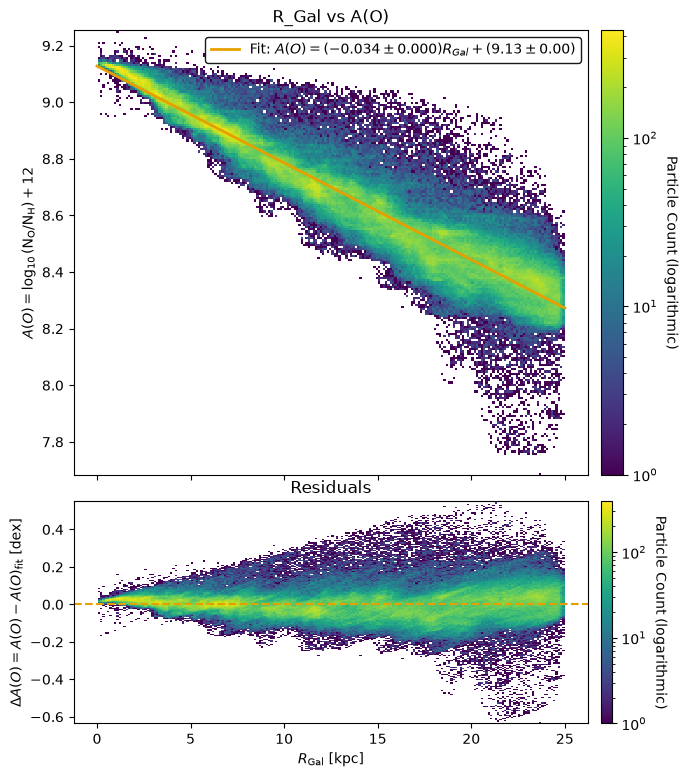

In [11]:
#Part 1 and 2 ---

import os
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit

os.makedirs('figures', exist_ok=True)

file_path = 'data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits'
with fits.open(file_path) as hdul:
    data = hdul[1].data
    x_positions = np.array(data['x'], dtype=np.float64)
    y_positions = np.array(data['y'], dtype=np.float64)
    z_positions = np.array(data['z'], dtype=np.float64)
    AO_values = np.array(data['A_O'], dtype=np.float64)

r_gal = np.sqrt(x_positions**2 + y_positions**2)

mask = (r_gal < 25) & np.isfinite(r_gal) & np.isfinite(AO_values)
r_gal_filtered = r_gal[mask]
AO_values_filtered = AO_values[mask]
x_values_filtered = x_positions[mask]
y_values_filtered = y_positions[mask]

def linear_model(r, slope, intercept):
    return slope * r + intercept

popt, pcov = curve_fit(linear_model, r_gal_filtered, AO_values_filtered, p0=[-0.5, 9.0])
slope, intercept = popt
slope_err, intercept_err = np.sqrt(np.diag(pcov))

AO_predicted = linear_model(r_gal_filtered, slope, intercept)
residuals = AO_values_filtered - AO_predicted

print(f"Slope: {slope:.5f} ± {slope_err:.5f} dex/kpc")
print(f"Intercept: {intercept:.4f} ± {intercept_err:.4f} dex")

fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True, 
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

#R_Gal vs A(O)
h1 = axes[0].hist2d(r_gal_filtered, AO_values_filtered, bins=[200,200], cmap='viridis', norm=LogNorm())
r_eval = np.linspace(0, 25, 200)
fit_label = f'Fit: $A(O) = ({slope:.3f} \\pm {slope_err:.3f}) R_{{Gal}} + ({intercept:.2f} \\pm {intercept_err:.2f})$'
axes[0].plot(r_eval, linear_model(r_eval, slope, intercept), color='#e69f00', label=fit_label, linewidth=2)
axes[0].set_ylabel(r'$A(O) = \log_{10}(\mathrm{N_O}/\mathrm{N_H}) + 12$')
axes[0].set_title('R_Gal vs A(O)')
axes[0].legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='black', framealpha=0.9)
cbar0 = fig.colorbar(h1[3], ax=axes[0], pad=0.02)
cbar0.set_label('Particle Count (logarithmic)', rotation=270, labelpad=15)

#Residuals R_Gal vs Delta A(O)
h2 = axes[1].hist2d(r_gal_filtered, residuals, bins=[200, 200], cmap='viridis', norm=LogNorm())

axes[1].axhline(y=0, color='#e69f00', linestyle='--', linewidth=1.5)
axes[1].set_xlabel(r'$R_{\mathrm{Gal}}$ [kpc]')
axes[1].set_ylabel(r'$\Delta A(O) = A(O) - A(O)_{\mathrm{fit}}$ [dex]')
axes[1].set_title('Residuals')

#Add the colorbar for the residuals density
cbar1 = fig.colorbar(h2[3], ax=axes[1], pad=0.02)
cbar1.set_label('Particle Count (logarithmic)', rotation=270, labelpad=15)
